In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = '6'

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
import torch
import os
from pathlib import Path
from mne.time_frequency import psd_array_multitaper
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np
from torch.nn import functional as F
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import requests
import pickle
import clip
import sys
sys.path.append('/home/ldy/Closed_loop_optimizing')
device = "cuda" if torch.cuda.is_available() else "cpu"
# vlmodel, preprocess = clip.load("ViT-B/32", device=device)
model_type = 'ViT-H-14'

# import open_clip
# vlmodel, preprocess_train, feature_extractor = open_clip.create_model_and_transforms(
#     model_type, pretrained='laion2b_s32b_b79k', precision='fp32', device=device)
# import json
from omegaconf import OmegaConf
from model.eegdatasets_leaveone import EEGDataset
selected_channel_idxes = slice(None)

/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ldy/miniconda3/envs/BCI/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/home/ldy/Closed_loop_optimizing/model/eegdatasets_leaveone.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle mo

In [2]:
def load_psd_from_eeg(eeg, fs=250, selected_channel_idxes=selected_channel_idxes):
    selected_eeg = eeg[selected_channel_idxes, :]
    psd_feature, _ = psd_array_multitaper(selected_eeg, fs, adaptive=True, normalization='full', verbose=0)
    return torch.from_numpy(psd_feature.flatten()).unsqueeze(0)

In [3]:
# cfg = OmegaConf.load(os.path.join("/mnt/dataset0/ldy/Workspace/FLORA/configs/config.yaml"))
# cfg = OmegaConf.structured(cfg)
# # Access the paths from the config
# img_directory_training = cfg.eegdataset.img_directory_training
# img_directory_test = cfg.eegdataset.img_directory_test

# # Instantiate the dataset and dataloader
# data_path = "/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/Preprocessed_data_250Hz"  # Replace with the path to your data
# data_path = data_path
# # train_dataset = EEGDataset(data_path, subjects = ['sub-01'], train=True)    
# test_dataset = EEGDataset(data_path, subjects = ['sub-01'], train=False)

# psd_features = []
# for i in range(200):
#     _, eeg, label, text, text_features, img, img_features, _ = test_dataset[i]
#     psd_feature = load_psd_from_eeg(eeg, fs=250, selected_channel_idxes=selected_channel_idxes)
#     psd_features.append(psd_feature)
    
# psd_features = torch.stack(psd_features)


In [4]:
# psd_features.shape

In [ ]:
# import os
# from pathlib import Path
# import numpy as np

# # 假设你已经有了以下配置和函数
# cfg = OmegaConf.load(os.path.join("/mnt/dataset0/ldy/Workspace/FLORA/configs/config.yaml"))
# cfg = OmegaConf.structured(cfg)

# # 定义输出目录
# output_dir = "/home/ldy/Closed_loop_optimizing/data/original_psd_feature"  # 请替换为你想要的输出目录
# Path(output_dir).mkdir(parents=True, exist_ok=True)  # 创建输出目录

# # 数据路径
# data_path = "/mnt/dataset0/ldy/4090_Workspace/4090_THINGS/Preprocessed_data_250Hz"

# # 定义所有subject列表 (假设sub-01到sub-10)
# subjects = [f'sub-{i:02d}' for i in range(1, 11)]

# # 处理每个subject
# for sub in subjects:
#     print(f"Processing subject: {sub}")
    
#     # 初始化该subject的psd_features列表
#     sub_psd_features = []
    
#     # 加载测试数据集
#     test_dataset = EEGDataset(data_path, subjects=[sub], train=False)
    
#     # 处理200个样本
#     for i in range(200):
#         try:
#             _, eeg, label, text, text_features, img, img_features, _ = test_dataset[i]
#             psd_feature = load_psd_from_eeg(eeg, fs=250, selected_channel_idxes=selected_channel_idxes)
#             sub_psd_features.append(psd_feature)
#         except Exception as e:
#             print(f"Error processing sample {i} for subject {sub}: {e}")
#             continue
    
    
    
#     # 保存到文件
#     output_path = os.path.join(output_dir, f"{sub}_psd_features_63channels.pt")
#     sub_psd_features = torch.stack(sub_psd_features)

#     torch.save(sub_psd_features, output_path)
#     print(f"Saved PSD features for {sub} to {output_path}")

# print("All subjects processed successfully!")

Processing subject: sub-01
self.subjects ['sub-01']
exclude_subject None
Data tensor shape: torch.Size([200, 63, 250]), label tensor shape: torch.Size([200]), text length: 200, image length: 200


/home/ldy/Closed_loop_optimizing/model/eegdatasets_leaveone.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  saved_features = torch.load(features_filename)


Saved PSD features for sub-01 to /home/ldy/Closed_loop_optimizing/data/original_psd_feature/sub-01_psd_features_63channels.pt
Processing subject: sub-02
self.subjects ['sub-02']
exclude_subject None
Data tensor shape: torch.Size([200, 63, 250]), label tensor shape: torch.Size([200]), text length: 200, image length: 200
Saved PSD features for sub-02 to /home/ldy/Closed_loop_optimizing/data/original_psd_feature/sub-02_psd_features_63channels.pt
Processing subject: sub-03
self.subjects ['sub-03']
exclude_subject None
Data tensor shape: torch.Size([200, 63, 250]), label tensor shape: torch.Size([200]), text length: 200, image length: 200
Saved PSD features for sub-03 to /home/ldy/Closed_loop_optimizing/data/original_psd_feature/sub-03_psd_features_63channels.pt
Processing subject: sub-04
self.subjects ['sub-04']
exclude_subject None
Data tensor shape: torch.Size([200, 63, 250]), label tensor shape: torch.Size([200]), text length: 200, image length: 200
Saved PSD features for sub-04 to /hom

In [ ]:
# sub_psd_features.shape

torch.Size([200, 1, 7938])

In [10]:
def plot_similarity_scatter(eeg_dir, eeg_image_embed, subject_id=None, batch_size=100, 
                          n_strata=5, output_path=None, modality='EEG',
                          line_color='b', fill_color='skyblue', color='blue'):
    """
    Plot similarity scatter plot with stratified sampling where:
    - batch_size: TOTAL number of samples to draw
    - n_strata: Number of strata to divide the data into
    - output_path: Path to save the plot (optional)
    - eeg_image_embed: Pre-loaded image embeddings tensor
    - line_color: Color for regression line (default: 'b' for blue)
    - fill_color: Color for confidence interval (default: 'skyblue')
    """
    # Ensure image embeddings are on CPU
    eeg_image_embed = eeg_image_embed.cpu()

        
    # Calculate samples per stratum (distribute batch_size across n_strata)
    samples_per_stratum = batch_size // n_strata
    remainder = batch_size % n_strata
    
    # Stratify based on image embedding norms
    image_norms = torch.norm(eeg_image_embed, dim=1)
    strata_bounds = np.quantile(image_norms, np.linspace(0, 1, n_strata + 1))
    
    # Perform stratified sampling
    selected_indices = []
    for i in range(n_strata):
        # Get stratum indices
        mask = (image_norms >= strata_bounds[i]) & (image_norms < strata_bounds[i+1])
        stratum_indices = torch.where(mask)[0].numpy()
        
        if len(stratum_indices) == 0:
            continue
            
        # Adjust sample count for remainder
        n_samples = samples_per_stratum + (1 if i < remainder else 0)
        n_samples = min(n_samples, len(stratum_indices))
        
        # Random sample from stratum
        selected = np.random.choice(stratum_indices, n_samples, replace=False)
        selected_indices.extend(selected)
    
    selected_indices = np.array(selected_indices)
    actual_batch_size = len(selected_indices)

    # Process EEG data
    if subject_id is not None:
        # Single subject mode
        eeg_path = os.path.join(eeg_dir, f"{subject_id}_psd_features_63channels.pt")
        
        eeg_embed = torch.load(eeg_path).cpu().squeeze(1)
        # print(f"eeg_embed {eeg_embed.shape}")  
        
        eeg_sim = cosine_similarity(eeg_embed[selected_indices])
        eeg_image_sim = cosine_similarity(eeg_image_embed[selected_indices])
        title = f'Subject {subject_id} ({actual_batch_size} samples from {n_strata} strata)'
    else:
        # 定义所有subject列表 (假设sub-01到sub-10)
        subjects = [f'sub-{i:02d}' for i in range(1, 11)]

        # subject_files = [os.path.join(eeg_dir, f, "eeg_features_ATMS_test.pt") for f in os.listdir(eeg_dir)]
        all_eeg_sim, all_eeg_image_sim = [], []
        
        for subject_id in subjects:
            eeg_embed = torch.load(os.path.join(eeg_dir, f"{subject_id}_psd_features_63channels.pt")).cpu().squeeze(1)       
                                               
            all_eeg_sim.append(cosine_similarity(eeg_embed[selected_indices]))
            all_eeg_image_sim.append(cosine_similarity(eeg_image_embed[selected_indices]))
        
        eeg_sim = np.mean(all_eeg_sim, axis=0)
        eeg_image_sim = np.mean(all_eeg_image_sim, axis=0)

    # Extract upper triangle for plotting
    eeg_sim_flat = eeg_sim[np.triu_indices(actual_batch_size, k=1)]
    eeg_image_sim_flat = eeg_image_sim[np.triu_indices(actual_batch_size, k=1)]

    # Create plot
    plt.figure(figsize=(9, 9))
    sns.set(style="white", palette="muted",  font_scale=1.2)
    sns.set_context("notebook", rc={"lines.linewidth": 2.5})

    # Scatter plot
    plt.scatter(eeg_sim_flat, eeg_image_sim_flat, color=color, alpha=0.6, edgecolor='w', linewidth=0.5)

    # Linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(eeg_sim_flat, eeg_image_sim_flat)
    x_line = np.linspace(eeg_sim_flat.min(), eeg_sim_flat.max(), 100)
    y_line = slope * x_line + intercept

    # Confidence interval
    def get_confidence_interval(x, y, x_new, confidence=0.95):
        n = len(x)
        y_hat = slope * x_new + intercept
        s_err = np.sqrt(np.sum((y - (slope * x + intercept))**2 / (n - 2)))
        t_val = stats.t.ppf((1 + confidence) / 2, df=n-2)
        ci = t_val * s_err * np.sqrt(1/n + (x_new - np.mean(x))**2 / np.sum((x - np.mean(x))**2))
        return y_hat - ci, y_hat + ci

    lower, upper = get_confidence_interval(eeg_sim_flat, eeg_image_sim_flat, x_line)

    # Plot regression and CI with custom colors
    plt.plot(x_line, y_line, f'{line_color}-', label=f'R={r_value:.2f}, p={p_value:.2e}')
    plt.fill_between(x_line, lower, upper, color=fill_color, alpha=0.4, label='95% Confidence Interval')

    plt.tick_params(axis='x', labelsize=30)  # 设置x轴刻度标签字体大小
    plt.tick_params(axis='y', labelsize=30)  # 设置x轴刻度标签字体大小

    # Formatting
    plt.xlabel(f'{modality} Feature Similarity', fontsize=40)
    plt.ylabel('Image Feature Similarity', fontsize=40)    
    
    plt.xlim(left=0)
    plt.ylim(bottom=0)
    sns.despine(left=False, bottom=False)
    plt.legend(loc='upper left', frameon=True, framealpha=0.9, fontsize=30)
    plt.grid(False)
    plt.tight_layout()

    # Handle output
    if output_path:
        Path(output_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()




In [11]:
import torch

img_embeds = torch.load("/mnt/dataset1/ldy/Workspace/FLORA/data_preparing/ViT-H-14_features_test.pt")['img_features'].cpu()

/tmp/ipykernel_1170071/3399699399.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  img_embeds = torch.load("/mnt/dataset1/ldy/Workspace/FLORA/data_preparing/ViT-H-14_feat

/tmp/ipykernel_1170071/50715564.py:51: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  eeg_embed = torch.load(eeg_path).cpu().squeeze(1)


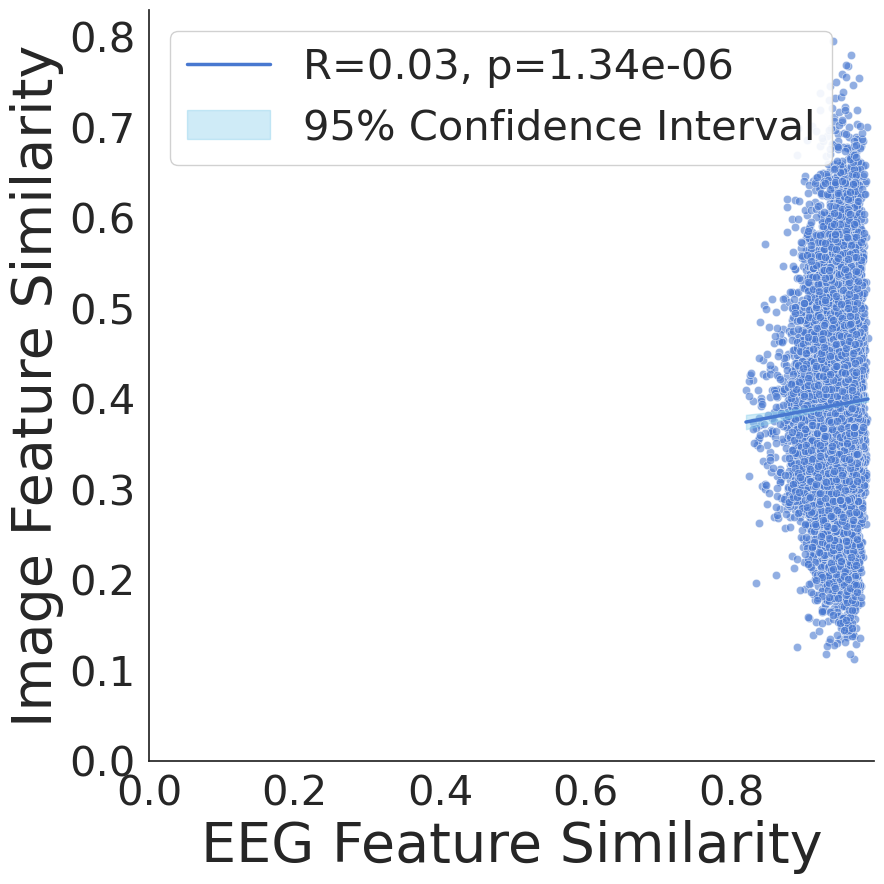

/tmp/ipykernel_1170071/50715564.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  eeg_embed = torch.load(os.path.join(eeg_dir, f"{subject_id}_psd_features_63channels.pt")

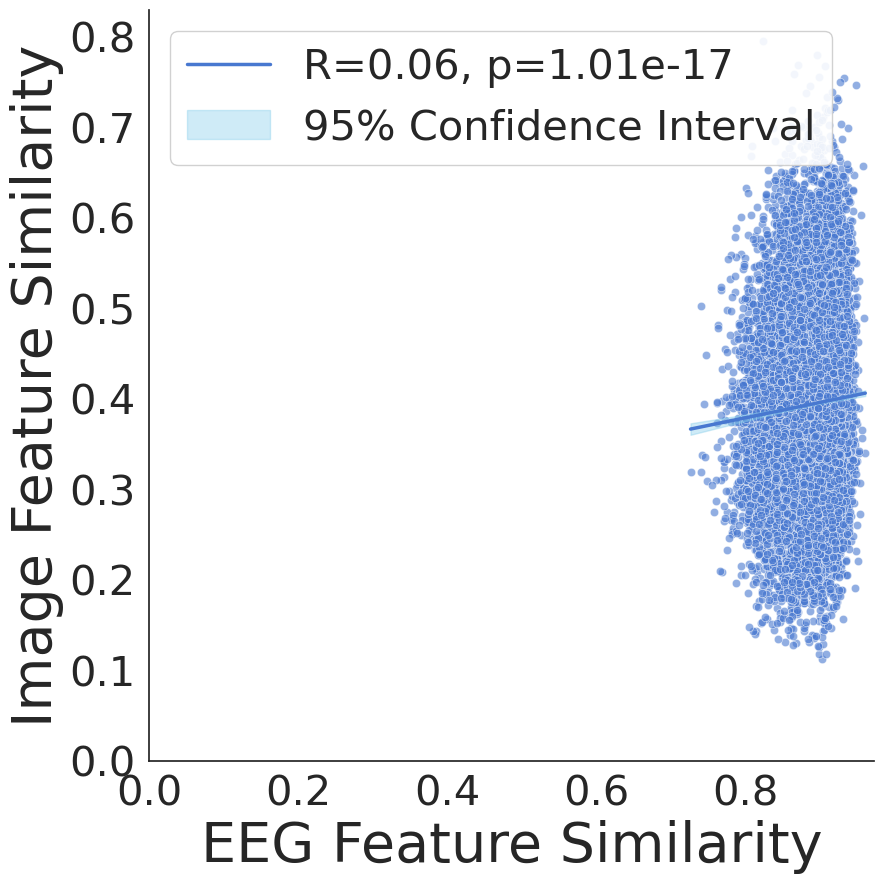

In [12]:
plot_similarity_scatter(
    eeg_dir='/home/ldy/Closed_loop_optimizing/data/original_psd_feature',
    eeg_image_embed=img_embeds,
    subject_id='sub-01',
    batch_size=200,
    n_strata=5,
    output_path='/home/ldy/Closed_loop_optimizing/plots/Interactive_search/EEG_image_scatter_sub-01.png',
    modality='EEG',
    line_color='b', 
    fill_color='skyblue',  
    color='b'
)

plot_similarity_scatter(
    eeg_dir='/home/ldy/Closed_loop_optimizing/data/original_psd_feature',
    eeg_image_embed=img_embeds,
    subject_id=None,
    batch_size=200,
    n_strata=5,
    output_path='/home/ldy/Closed_loop_optimizing/plots/Interactive_search/EEG_image_scatter_avg.png',
    modality='EEG',
    line_color='b', 
    fill_color='skyblue',  
    color='b'
)